In [154]:
!nvidia-smi

Thu Apr 30 08:19:17 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   77C    P0             32W /   70W |     227MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [155]:
!pip install -q -U watermark
%reload_ext watermark
%watermark -v -p numpy,pandas,torch

Python implementation: CPython
Python version       : 3.12.13
IPython version      : 7.34.0

numpy : 2.0.2
pandas: 2.2.2
torch : 2.10.0+cu128



In [156]:
# Heavily based on https://github.com/Prodicode/ann-visualizer

def ann_viz(model, view=True, filename="network.gv"):
    """Vizualizez a Sequential model.

    # Arguments
        model: A Keras model instance.

        view: whether to display the model after generation.

        filename: where to save the vizualization. (a .gv file)

        title: A title for the graph
    """
    from graphviz import Digraph

    input_layer = 0
    hidden_layers_nr = 0
    layer_types = []
    hidden_layers = []
    output_layer = 0
    layers = [layer for layer in model.modules() if type(layer) == torch.nn.Linear]

    for layer in layers:
        if layer == layers[0]:
            input_layer = layer.in_features
            hidden_layers_nr += 1
            if type(layer) == torch.nn.Linear:
                hidden_layers.append(layer.out_features)
                layer_types.append("Dense")
            else:
                raise Exception("Input error")

        else:
            if layer == layers[-1]:
                output_layer = layer.out_features
            else:
                hidden_layers_nr += 1
                if type(layer) == torch.nn.Linear:

                    hidden_layers.append(layer.out_features)
                    layer_types.append("Dense")
                else:
                    raise Exception("Hidden error")
        last_layer_nodes = input_layer
        nodes_up = input_layer

    g = Digraph("g", filename=filename)
    n = 0
    g.graph_attr.update(splines="false", nodesep="0.5", ranksep="0", rankdir='LR')
    # Input Layer
    with g.subgraph(name="cluster_input") as c:
        if type(layers[0]) == torch.nn.Linear:
            the_label = "Input Layer"
            if layers[0].in_features > 10:
                the_label += " (+" + str(layers[0].in_features - 10) + ")"
                input_layer = 10
            c.attr(color="white")
            for i in range(0, input_layer):
                n += 1
                c.node(str(n))
                c.attr(labeljust="1")
                c.attr(label=the_label, labelloc="bottom")
                c.attr(rank="same")
                c.node_attr.update(
                    width="0.65",
                    style="filled",
                    shape="circle",
                    color=HAPPY_COLORS_PALETTE[3],
                    fontcolor=HAPPY_COLORS_PALETTE[3],
                )
    for i in range(0, hidden_layers_nr):
        with g.subgraph(name="cluster_" + str(i + 1)) as c:
            if layer_types[i] == "Dense":
                c.attr(color="white")
                c.attr(rank="same")
                the_label = f'Hidden Layer {i + 1}'
                if layers[i].out_features > 10:
                    the_label += " (+" + str(layers[i].out_features - 10) + ")"
                    hidden_layers[i] = 10
                c.attr(labeljust="right", labelloc="b", label=the_label)
                for j in range(0, hidden_layers[i]):
                    n += 1
                    c.node(
                        str(n),
                        width="0.65",
                        shape="circle",
                        style="filled",
                        color=HAPPY_COLORS_PALETTE[0],
                        fontcolor=HAPPY_COLORS_PALETTE[0],
                    )
                    for h in range(nodes_up - last_layer_nodes + 1, nodes_up + 1):
                        g.edge(str(h), str(n))
                last_layer_nodes = hidden_layers[i]
                nodes_up += hidden_layers[i]
            else:
                raise Exception("Hidden layer type not supported")

    with g.subgraph(name="cluster_output") as c:
        if type(layers[-1]) == torch.nn.Linear:
            c.attr(color="white")
            c.attr(rank="same")
            c.attr(labeljust="1")
            for i in range(1, output_layer + 1):
                n += 1
                c.node(
                    str(n),
                    width="0.65",
                    shape="circle",
                    style="filled",
                    color=HAPPY_COLORS_PALETTE[4],
                    fontcolor=HAPPY_COLORS_PALETTE[4],

                )
                for h in range(nodes_up - last_layer_nodes + 1, nodes_up + 1):
                    g.edge(str(h), str(n))
            c.attr(label="Output Layer", labelloc="bottom")
            c.node_attr.update(
                color="#2ecc71", style="filled", fontcolor="#2ecc71", shape="circle"
            )

    g.attr(arrowShape="none")
    g.edge_attr.update(arrowhead="none", color="#707070", penwidth="2")
    if view is True:
        g.view()

    return g


In [157]:
import torch

import os
import numpy as np
import pandas as pd
from tqdm import tqdm
import seaborn as sns
from pylab import rcParams
import matplotlib.pyplot as plt
from matplotlib import rc
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

from torch import nn, optim

import torch.nn.functional as F

%matplotlib inline
%config InlineBackend.figure_format='retina'

sns.set(style='whitegrid', palette='muted', font_scale=1.2)

HAPPY_COLORS_PALETTE = ["#01BEFE", "#FFDD00", "#FF7D00", "#FF006D", "#93D30C", "#8F00FF"]

sns.set_palette(sns.color_palette(HAPPY_COLORS_PALETTE))

rcParams['figure.figsize'] = 12, 8

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

In [158]:
#!gdown --id 1Q1wUptbNDYdfizk5abhmoFxIQiX19Tn7
#df = pd.read_csv('weatherAUS.csv')
#df.head()
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "weatherAUS.csv"

# Load the latest version in a data frame
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "jsphyg/weather-dataset-rattle-package",
  file_path)

print("First 5 records:", df.head())

/tmp/ipykernel_1331/1083403137.py:13: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


Using Colab cache for faster access to the 'weather-dataset-rattle-package' dataset.
First 5 records:          Date Location  MinTemp  MaxTemp  Rainfall  Evaporation  Sunshine  \
0  2008-12-01   Albury     13.4     22.9       0.6          NaN       NaN   
1  2008-12-02   Albury      7.4     25.1       0.0          NaN       NaN   
2  2008-12-03   Albury     12.9     25.7       0.0          NaN       NaN   
3  2008-12-04   Albury      9.2     28.0       0.0          NaN       NaN   
4  2008-12-05   Albury     17.5     32.3       1.0          NaN       NaN   

  WindGustDir  WindGustSpeed WindDir9am  ... Humidity9am  Humidity3pm  \
0           W           44.0          W  ...        71.0         22.0   
1         WNW           44.0        NNW  ...        44.0         25.0   
2         WSW           46.0          W  ...        38.0         30.0   
3          NE           24.0         SE  ...        45.0         16.0   
4           W           41.0        ENE  ...        82.0         33.0 

In [159]:
df.shape

(145460, 23)

Looks like we have plenty of data. But we got to do something about those missing values.

In [160]:
cols = ['Rainfall', 'Humidity3pm', 'Pressure9am', 'RainToday', 'RainTomorrow']

df = df[cols]

In [161]:
df['RainToday'].replace({'No': 0, 'Yes': 1}, inplace = True)
df['RainTomorrow'].replace({'No': 0, 'Yes': 1}, inplace = True)

/tmp/ipykernel_1331/3734455367.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['RainToday'].replace({'No': 0, 'Yes': 1}, inplace = True)
/tmp/ipykernel_1331/3734455367.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['RainToday'].replace({'No': 0, 'Yes': 1}, inplace = True)
/tmp/ipykern

In [162]:
df = df.dropna(how='any')
df.head()

,Rainfall,Humidity3pm,Pressure9am,RainToday,RainTomorrow
0,0.6,22.0,1007.7,0.0,0.0
1,0.0,25.0,1010.6,0.0,0.0
2,0.0,30.0,1007.6,0.0,0.0
3,0.0,16.0,1017.6,0.0,0.0
4,1.0,33.0,1010.8,0.0,0.0


In [163]:
#sns.countplot(df.RainTomorrow);

In [164]:
df.RainTomorrow.value_counts() / df.shape[0]

,count
RainTomorrow,
0.0,0.778762
1.0,0.221238


In [165]:
X = df[['Rainfall', 'Humidity3pm', 'RainToday', 'Pressure9am']]
y = df[['RainTomorrow']]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_SEED)

In [166]:
X_train = torch.from_numpy(X_train.to_numpy()).float()
y_train = torch.squeeze(torch.from_numpy(y_train.to_numpy()).float())

X_test = torch.from_numpy(X_test.to_numpy()).float()
y_test = torch.squeeze(torch.from_numpy(y_test.to_numpy()).float())

print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

torch.Size([99751, 4]) torch.Size([99751])
torch.Size([24938, 4]) torch.Size([24938])


In [167]:
class Net(nn.Module):

  def __init__(self, n_features):
    super(Net, self).__init__()
    self.fc1 = nn.Linear(n_features,20)
    self.fc2 = nn.Linear(20, 16)
    self.fc3 = nn.Linear(16, 8)
    self.fc4 = nn.Linear(8, 1) # Ensure the last layer outputs 1 feature

  def forward(self, x):
    x = F.relu(self.fc1(x))
    x = F.relu(self.fc2(x))
    x = F.relu(self.fc3(x))
    x = self.fc4(x) # Removed the extra F.relu here
    return torch.sigmoid(x)

In [168]:
# Define helper functions
def calculate_accuracy(y_true, y_pred):
    predicted = y_pred.ge(.5).view(-1)
    return (y_true == predicted).sum().float() / len(y_true)

# Force CPU
device = torch.device("cpu")

# Move data to CPU
X_train = X_train.to(device)
y_train = y_train.to(device)
X_test = X_test.to(device)
y_test = y_test.to(device)

# Initialize model on CPU
net = Net(X_train.shape[1]).to(device)

# Loss and optimizer
criterion = nn.BCELoss().to(device)
optimizer = optim.Adam(net.parameters(), lr=0.001)

In [169]:
def round_tensor(t, decimal_places=3):
  return round(t.item(), decimal_places)

for epoch in range(10):

    y_pred = net(X_train)

    y_pred = torch.squeeze(y_pred)
    train_loss = criterion(y_pred, y_train)

    train_acc = calculate_accuracy(y_train, y_pred)
    y_test_pred = net(X_test)
    y_test_pred = torch.squeeze(y_test_pred)

    test_loss = criterion(y_test_pred, y_test)

    test_acc = calculate_accuracy(y_test, y_test_pred)
    print(f'''epoch {epoch}: Training loss: {round_tensor(train_loss)}, Training accuracy: {round_tensor(train_acc)}, Test loss: {round_tensor(test_loss)}, Test accuracy: {round_tensor(test_acc)}''')

    optimizer.zero_grad()

    train_loss.backward()

    optimizer.step()

epoch 0: Training loss: 0.617, Training accuracy: 0.785, Test loss: 0.618, Test accuracy: 0.786
epoch 1: Training loss: 0.563, Training accuracy: 0.781, Test loss: 0.564, Test accuracy: 0.78
epoch 2: Training loss: 0.552, Training accuracy: 0.78, Test loss: 0.553, Test accuracy: 0.779
epoch 3: Training loss: 0.566, Training accuracy: 0.779, Test loss: 0.567, Test accuracy: 0.778
epoch 4: Training loss: 0.565, Training accuracy: 0.779, Test loss: 0.566, Test accuracy: 0.778
epoch 5: Training loss: 0.553, Training accuracy: 0.779, Test loss: 0.554, Test accuracy: 0.778
epoch 6: Training loss: 0.543, Training accuracy: 0.779, Test loss: 0.543, Test accuracy: 0.779
epoch 7: Training loss: 0.543, Training accuracy: 0.779, Test loss: 0.544, Test accuracy: 0.779
epoch 8: Training loss: 0.547, Training accuracy: 0.78, Test loss: 0.548, Test accuracy: 0.779
epoch 9: Training loss: 0.547, Training accuracy: 0.78, Test loss: 0.547, Test accuracy: 0.779


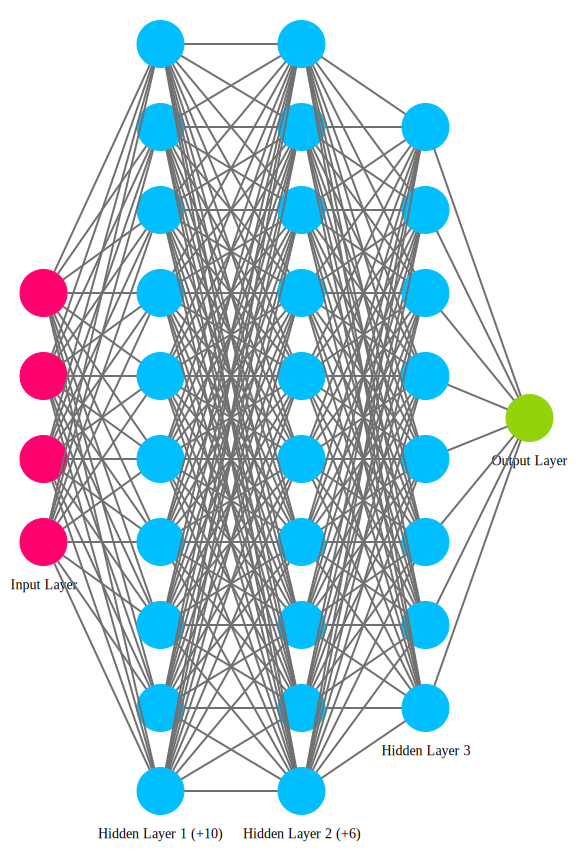

In [170]:
net = Net(X_train.shape[1])

ann_viz(net, view=False)

In [171]:
def round_tensor(t, decimal_places=3):
  return round(t.item(), decimal_places)

for epoch in range(10):

    y_pred = net(X_train)

    y_pred = torch.squeeze(y_pred)
    train_loss = criterion(y_pred, y_train)

    train_acc = calculate_accuracy(y_train, y_pred)
    y_test_pred = net(X_test)
    y_test_pred = torch.squeeze(y_test_pred)

    test_loss = criterion(y_test_pred, y_test)

    test_acc = calculate_accuracy(y_test, y_test_pred)
    print(f'''epoch {epoch}: Training loss: {round_tensor(train_loss)}, Training accuracy: {round_tensor(train_acc)}, Test loss: {round_tensor(test_loss)}, Test accuracy: {round_tensor(test_acc)}''')

    optimizer.zero_grad()

    train_loss.backward()

    optimizer.step()

epoch 0: Training loss: 1.705, Training accuracy: 0.779, Test loss: 1.708, Test accuracy: 0.778
epoch 1: Training loss: 1.705, Training accuracy: 0.779, Test loss: 1.708, Test accuracy: 0.778
epoch 2: Training loss: 1.705, Training accuracy: 0.779, Test loss: 1.708, Test accuracy: 0.778
epoch 3: Training loss: 1.705, Training accuracy: 0.779, Test loss: 1.708, Test accuracy: 0.778
epoch 4: Training loss: 1.705, Training accuracy: 0.779, Test loss: 1.708, Test accuracy: 0.778
epoch 5: Training loss: 1.705, Training accuracy: 0.779, Test loss: 1.708, Test accuracy: 0.778
epoch 6: Training loss: 1.705, Training accuracy: 0.779, Test loss: 1.708, Test accuracy: 0.778
epoch 7: Training loss: 1.705, Training accuracy: 0.779, Test loss: 1.708, Test accuracy: 0.778
epoch 8: Training loss: 1.705, Training accuracy: 0.779, Test loss: 1.708, Test accuracy: 0.778
epoch 9: Training loss: 1.705, Training accuracy: 0.779, Test loss: 1.708, Test accuracy: 0.778


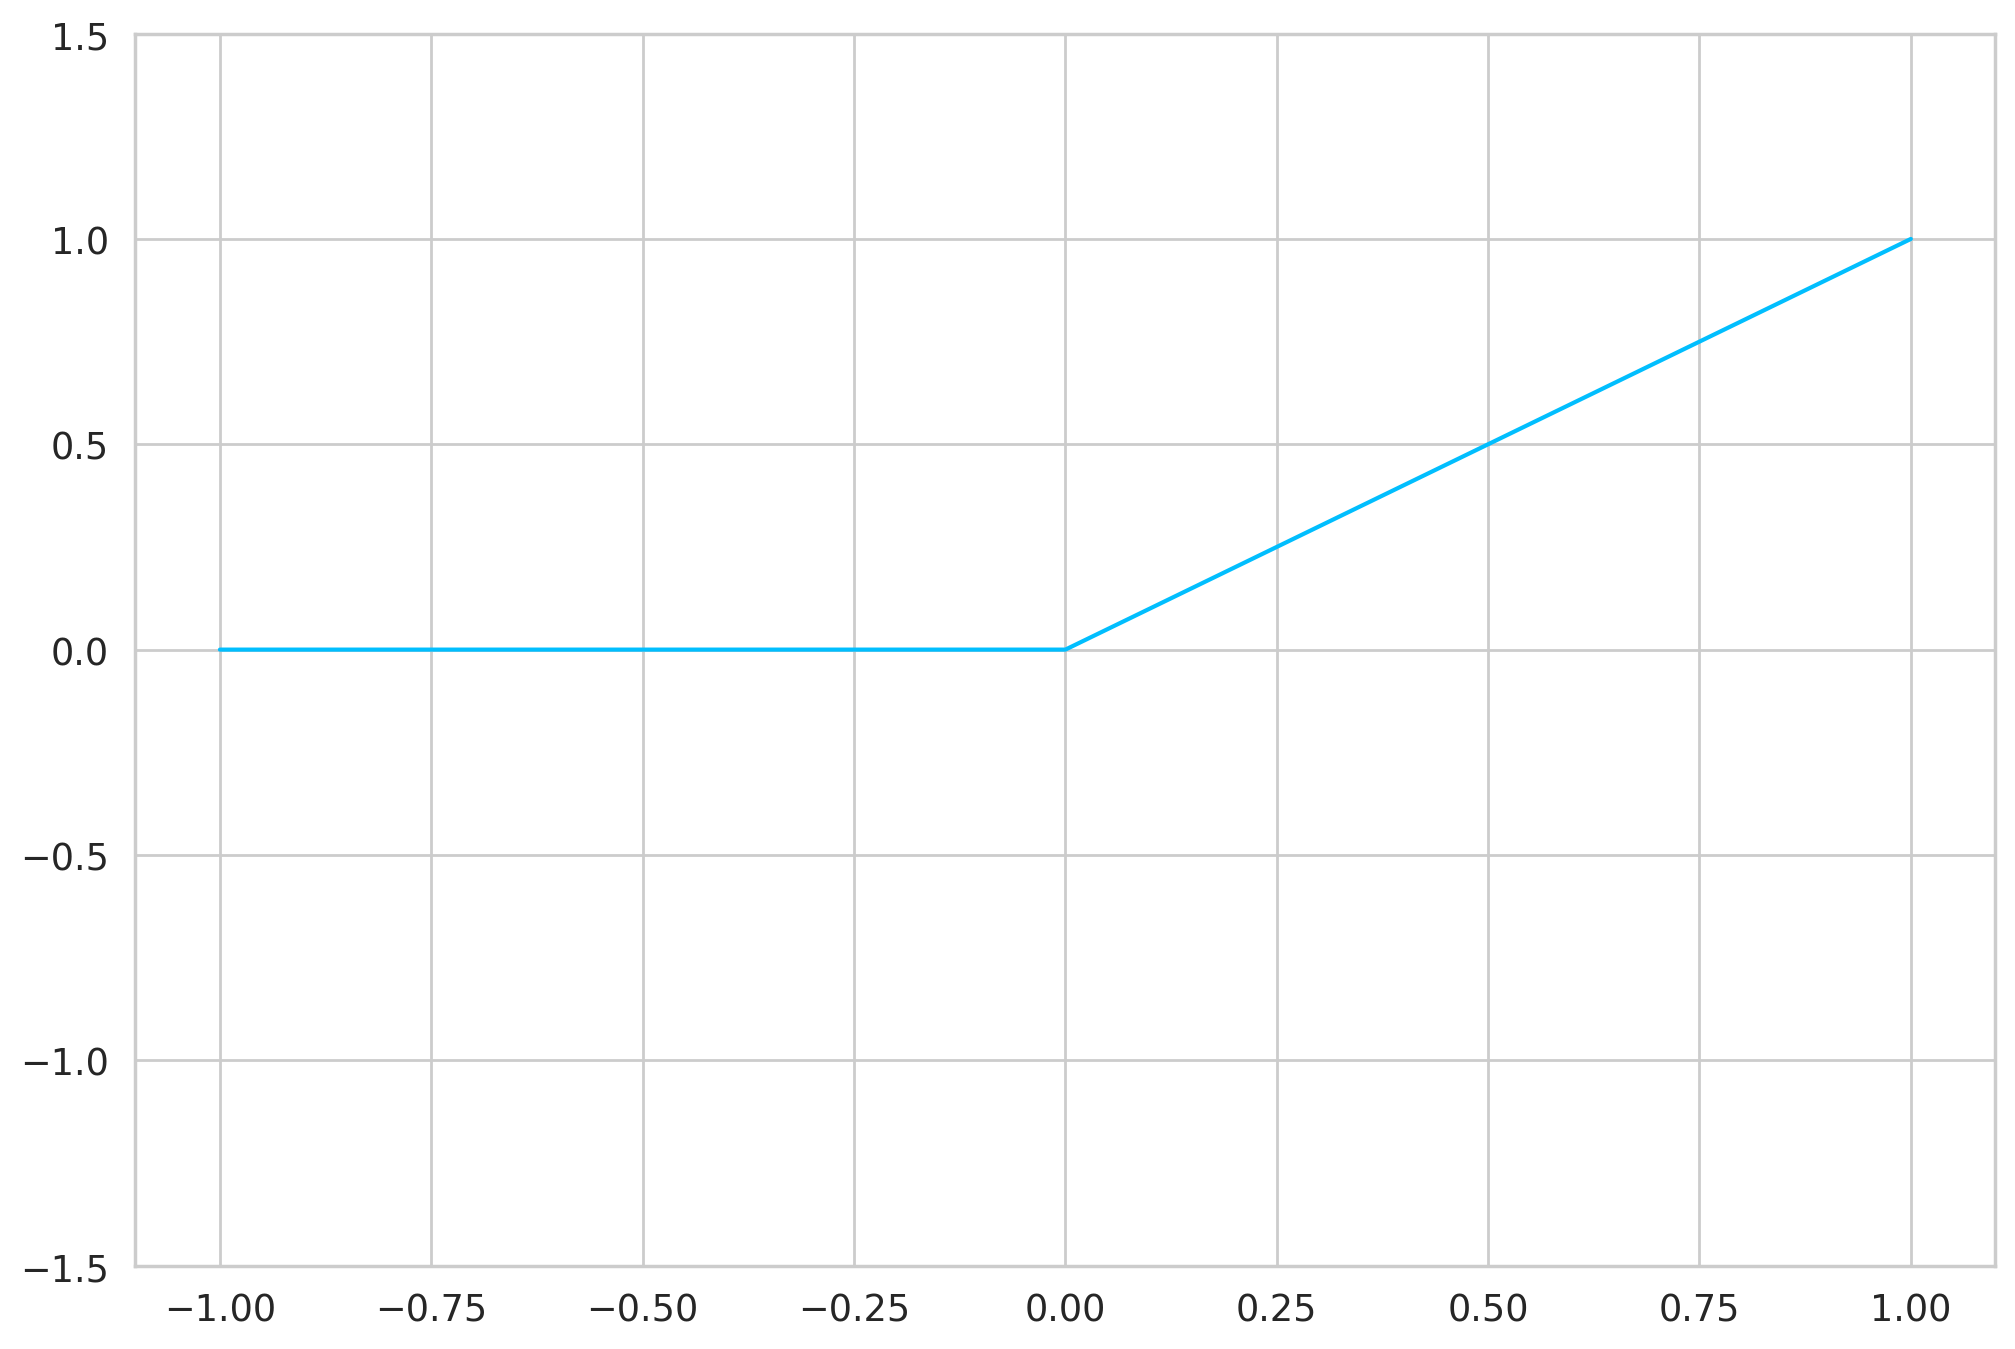

In [172]:
ax = plt.gca()

plt.plot(
  np.linspace(-1, 1, 5),
  F.relu(torch.linspace(-1, 1, steps=5)).numpy()
)
ax.set_ylim([-1.5, 1.5]);

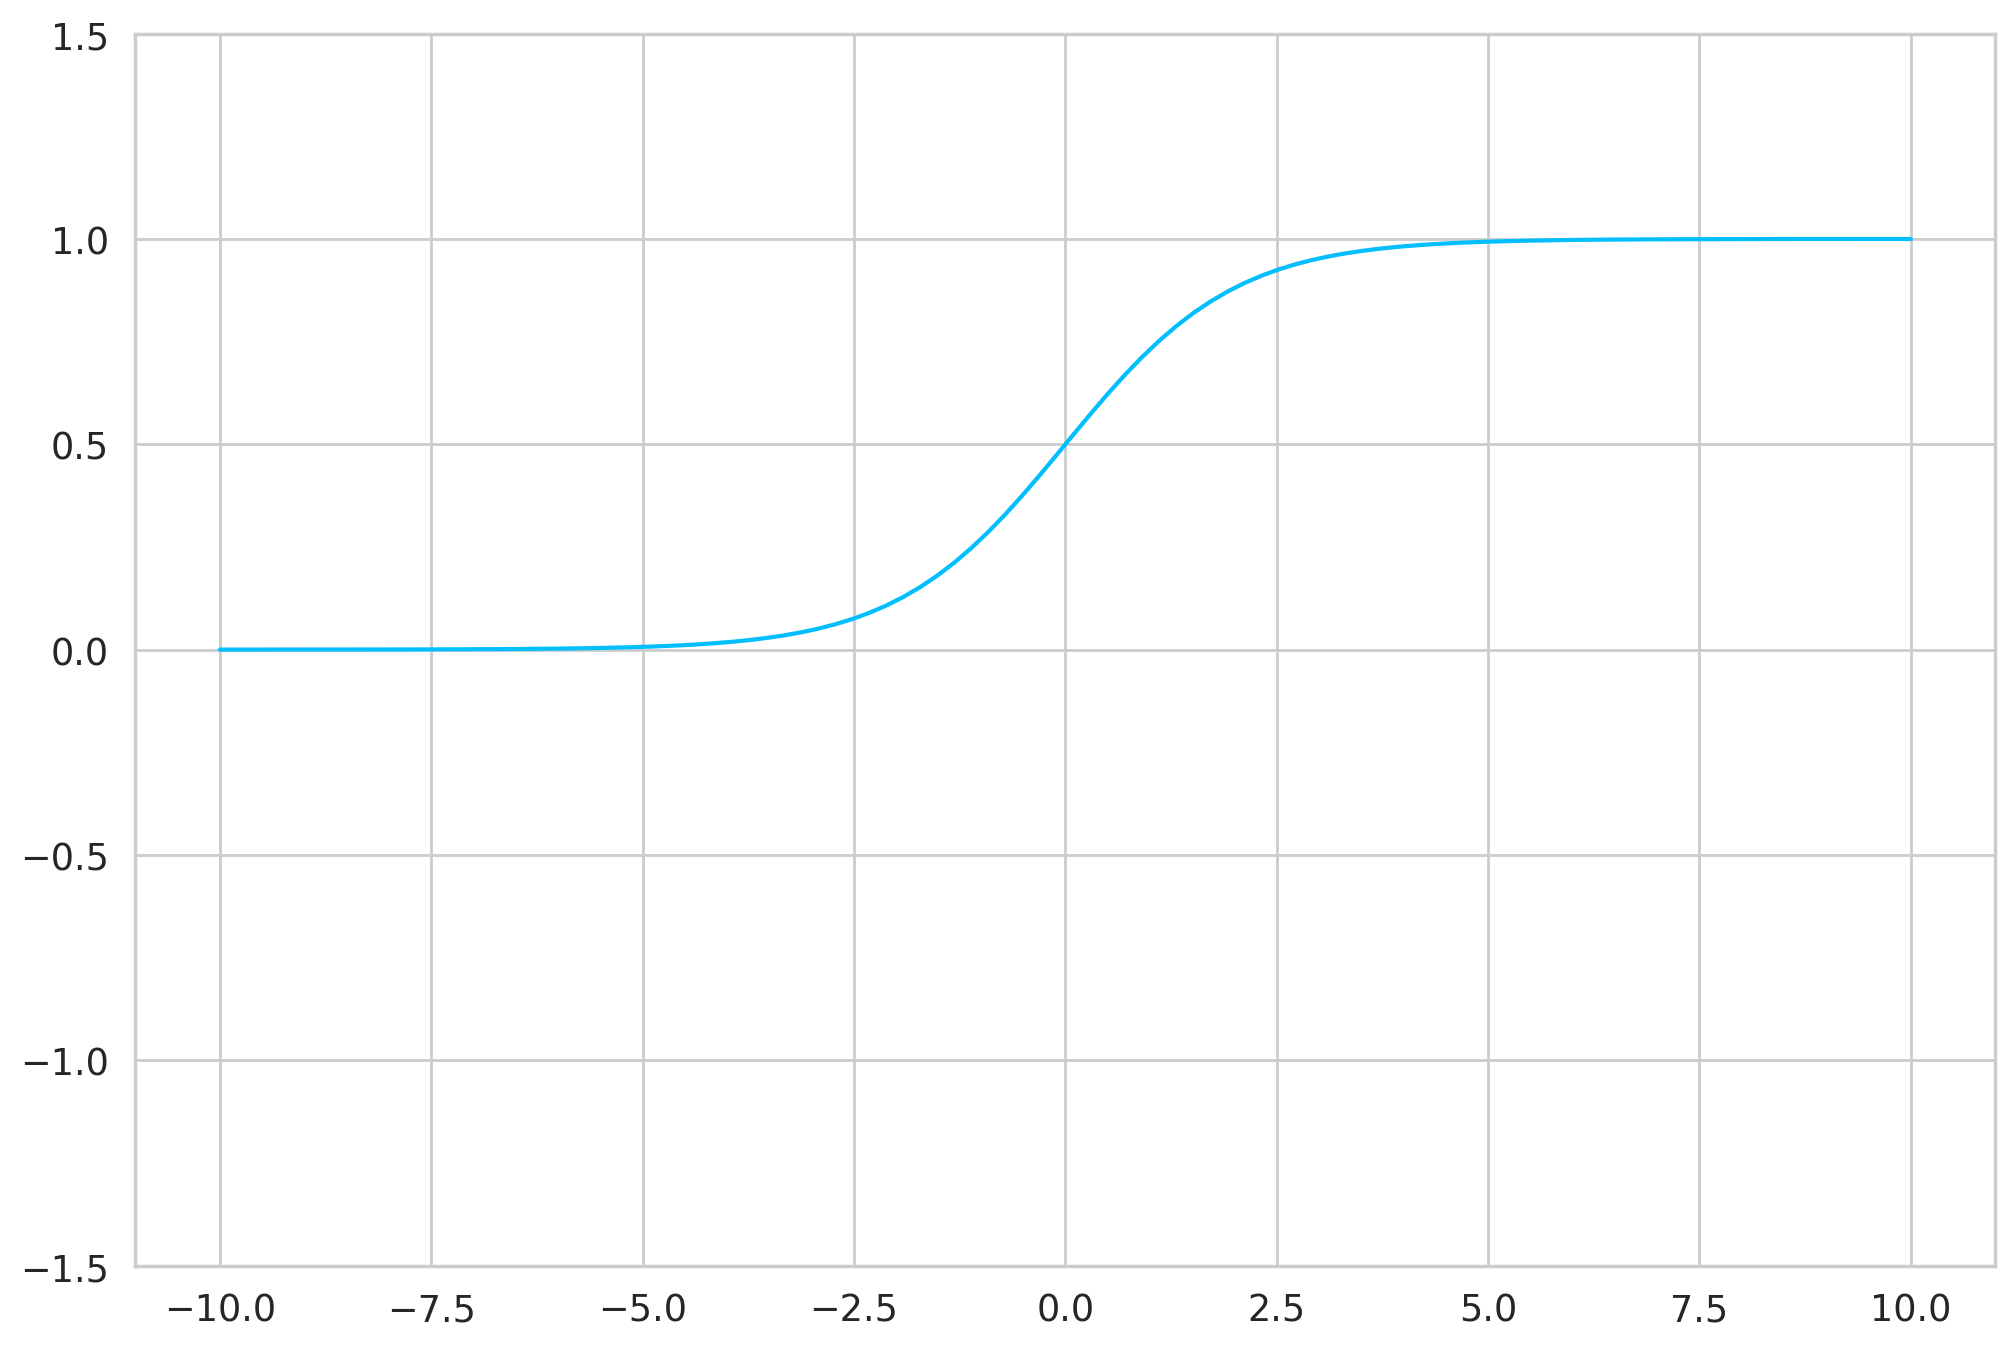

In [173]:
ax = plt.gca()

plt.plot(
  np.linspace(-10, 10, 100),
  torch.sigmoid(torch.linspace(-10, 10, steps=100)).numpy()
)
ax.set_ylim([-1.5, 1.5]);

In [174]:
criterion = nn.BCELoss()

In [175]:
optimizer = optim.Adam(net.parameters(), lr=0.001)

In [176]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [177]:
X_train = X_train.to(device)
y_train = y_train.to(device)

X_test = X_test.to(device)
y_test = y_test.to(device)

In [178]:
net = net.to(device)

criterion = criterion.to(device)

In [179]:
def calculate_accuracy(y_true, y_pred):
  predicted = y_pred.ge(.5).view(-1)
  return (y_true == predicted).sum().float() / len(y_true)

In [180]:
def round_tensor(t, decimal_places=3):
  return round(t.item(), decimal_places)

for epoch in range(10):

    y_pred = net(X_train)

    y_pred = torch.squeeze(y_pred)
    train_loss = criterion(y_pred, y_train)

    train_acc = calculate_accuracy(y_train, y_pred)
    y_test_pred = net(X_test)
    y_test_pred = torch.squeeze(y_test_pred)

    test_loss = criterion(y_test_pred, y_test)

    test_acc = calculate_accuracy(y_test, y_test_pred)
    print(f'''epoch {epoch}: Training loss: {round_tensor(train_loss)}, Training accuracy: {round_tensor(train_acc)}, Test loss: {round_tensor(test_loss)}, Test accuracy: {round_tensor(test_acc)}''')

    optimizer.zero_grad()

    train_loss.backward()

    optimizer.step()

epoch 0: Training loss: 1.705, Training accuracy: 0.779, Test loss: 1.708, Test accuracy: 0.778
epoch 1: Training loss: 1.553, Training accuracy: 0.779, Test loss: 1.556, Test accuracy: 0.778
epoch 2: Training loss: 1.405, Training accuracy: 0.779, Test loss: 1.408, Test accuracy: 0.778
epoch 3: Training loss: 1.262, Training accuracy: 0.779, Test loss: 1.264, Test accuracy: 0.778
epoch 4: Training loss: 1.123, Training accuracy: 0.779, Test loss: 1.125, Test accuracy: 0.778
epoch 5: Training loss: 0.991, Training accuracy: 0.779, Test loss: 0.992, Test accuracy: 0.778
epoch 6: Training loss: 0.866, Training accuracy: 0.779, Test loss: 0.867, Test accuracy: 0.778
epoch 7: Training loss: 0.752, Training accuracy: 0.779, Test loss: 0.754, Test accuracy: 0.778
epoch 8: Training loss: 0.656, Training accuracy: 0.779, Test loss: 0.657, Test accuracy: 0.778
epoch 9: Training loss: 0.583, Training accuracy: 0.779, Test loss: 0.584, Test accuracy: 0.778


In [181]:
MODEL_PATH = 'model.pth'

torch.save(net, MODEL_PATH)

In [182]:
net = torch.load(MODEL_PATH, weights_only=False)

In [183]:
classes = ['No rain', 'Raining']

y_pred = net(X_test)

y_pred = y_pred.ge(.5).view(-1).cpu()
y_test = y_test.cpu()

print(classification_report(y_test, y_pred, target_names=classes))

              precision    recall  f1-score   support

     No rain       0.78      1.00      0.88     19413
     Raining       0.00      0.00      0.00      5525

    accuracy                           0.78     24938
   macro avg       0.39      0.50      0.44     24938
weighted avg       0.61      0.78      0.68     24938



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


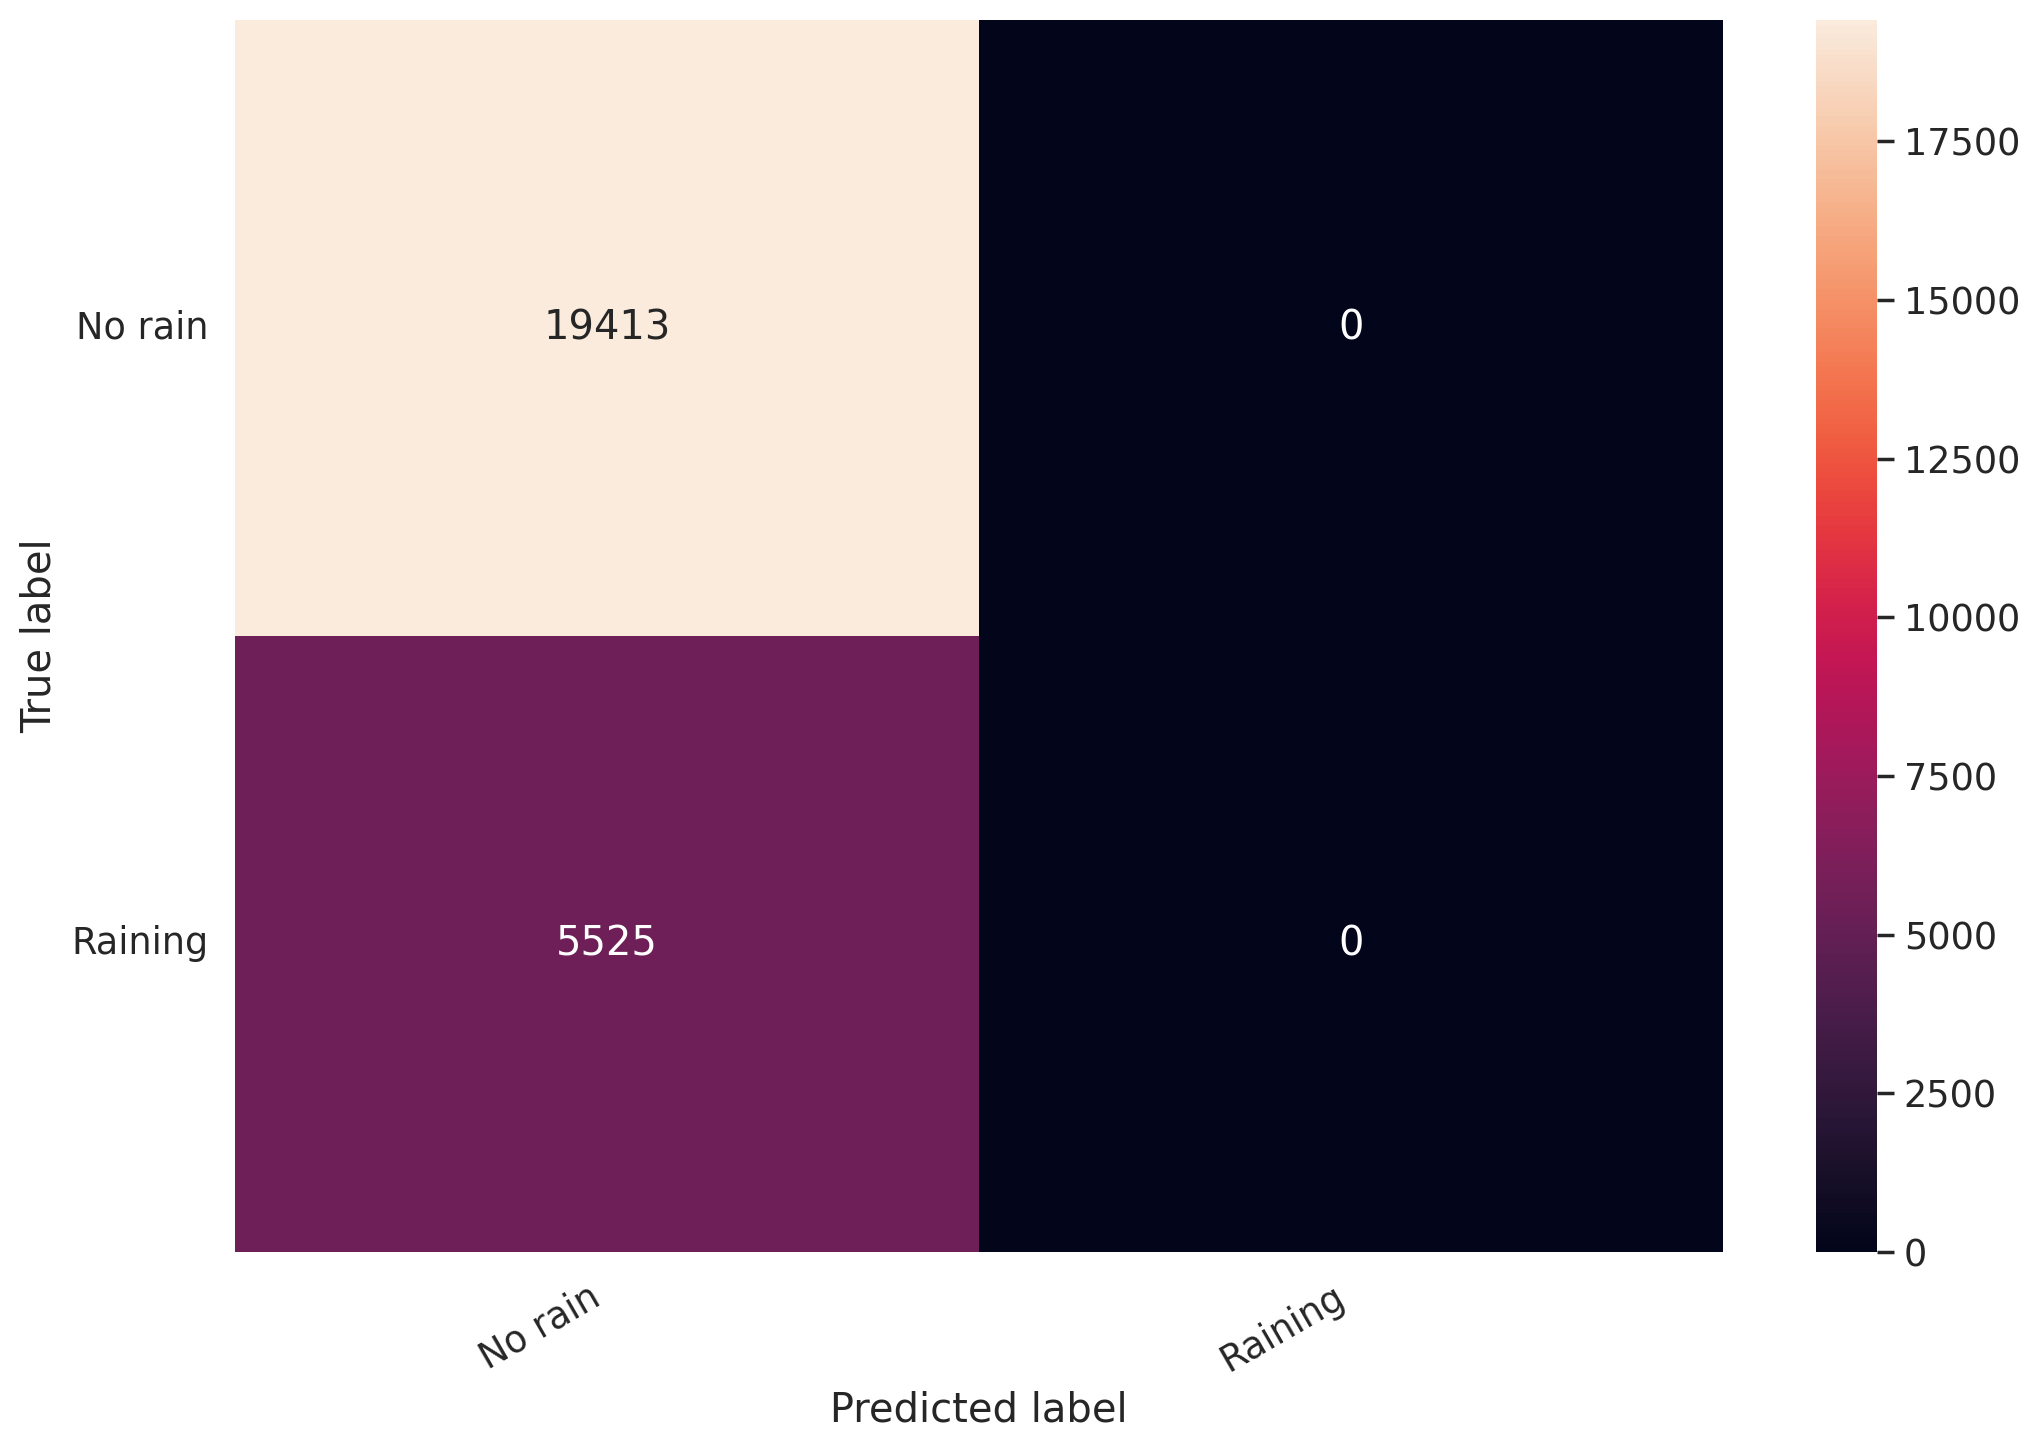

In [184]:
cm = confusion_matrix(y_test, y_pred)
df_cm = pd.DataFrame(cm, index=classes, columns=classes)

hmap = sns.heatmap(df_cm, annot=True, fmt="d")
hmap.yaxis.set_ticklabels(hmap.yaxis.get_ticklabels(), rotation=0, ha='right')
hmap.xaxis.set_ticklabels(hmap.xaxis.get_ticklabels(), rotation=30, ha='right')
plt.ylabel('True label')
plt.xlabel('Predicted label');